In [ ]:
!pip install --upgrade pip
!python -m pip install -U uv
!uv pip install --system -U transformers trl peft datasets accelerate bitsandbytes huggingface_hub pillow qwen_vl_utils
!uv pip install ms-swift==v4.0.0 https://github.com/Dao-AILab/flash-attention/releases/download/v2.8.3/flash_attn-2.8.3+cu12torch2.4cxx11abiFALSE-cp310-cp310-linux_x86_64.whl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 90.9 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:


In [ ]:
import gc
import torch

# delete large objects if exist
for v in ["model", "trainer", "optimizer", "inputs", "outputs", "batch"]:
    if v in globals():
        del globals()[v]

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

print("GPU cleared")

GPU cleared


In [ ]:
model_id = "Qwen/Qwen3.5-27B"
dataset_id = "asafd60/FineTree-annotated-pages-train"

In [ ]:
!MAX_PIXELS=1000000 \
CUDA_VISIBLE_DEVICES=0 \
swift sft \
  --model Qwen/Qwen3.5-27B \
  --tuner_type lora \
  --use_hf true \
  --dataset asafd60/FineTree_V2-approved-no-bbox-train \
  --val_dataset asafd60/FineTree_V2-approved-no-bbox-validation \
  --load_from_cache_file true \
  --freeze_vit False \
  --vit_lr 5e-6 \
  --freeze_aligner False \
  --enable_thinking false \
  --add_non_thinking_prefix true \
  --torch_dtype bfloat16 \
  --num_train_epochs 8 \
  --per_device_train_batch_size 1 \
  --per_device_eval_batch_size 1 \
  --learning_rate 1e-4 \
  --lora_rank 4 \
  --lora_alpha 16 \
  --target_modules all-linear \
  --gradient_accumulation_steps 16 \
  --output_dir output/Qwen3.5-27B \
  --eval_steps 5 \
  --save_steps 5 \
  --save_total_limit 3 \
  --logging_steps 5 \
  --max_length 6250 \
  --warmup_ratio 0.03 \
  --dataset_num_proc 3 \
  --dataloader_num_workers 3 \
  --eval_on_start true \
  --max_pixels 1_000_000 \
  --temperature 0 \
  --gradient_checkpointing true \
  --gradient_checkpointing_kwargs '{"use_reentrant": false}' \
  --truncation_strategy right

Streaming output truncated to the last 5000 lines.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[INFO:swift] output_dir: /content/output/Qwen3.5-27B/v0-20260313-130558
[INFO:swift] args: SftArguments(
acc_strategy=token,
accelerator_config={'dispatch_batches': False},
adalora_beta1=0.85,
adalora_beta2=0.85,
adalora_deltaT=1,
adalora_init_r=12,
adalora_orth_reg_weight=0.5,
adalora_target_r=8,
adalora_tfinal=0,
adalora_tinit=0,
adam_beta1=0.9,
adam_beta2=0.95,
adam_epsilon=1e-08,
adapter_act=gelu,
adapter_length=128,
adapters=[],
add_non_thinking_prefix=True,
add_version=True,
agent_template=None,
aligner_lr=None,
attn_impl=None,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=True,
bf16_full_eval=False,
bnb_4bit_compute_dtype=torch.bfloat16,
bnb_4bit_quant_storage=None,
bnb_4bit_quant_type=nf4,
bnb_4bit_use_double_quant=True,
boft_block_num=0,
boft_block_size=4,
boft_dropout=0.0,
boft_n_butterfly_facto

In [ ]:
!CUDA_VISIBLE_DEVICES=0 \
MAX_PIXELS=1000000 \
swift infer \
    --model Qwen/Qwen3.5-27B \
    --adapters /content/output/Qwen3.5-27B/v5-20260305-101842/checkpoint-6 \
    --stream true \
    --infer_backend transformers \
    --enable_thinking false \
    --add_non_thinking_prefix true \
    --use_hf true \
    --val_dataset asafd60/FineTree-annotated-pages-no-bbox-validation  \
    --max_new_tokens 500 \
    --temperature 0

In [ ]:
!CUDA_VISIBLE_DEVICES=0 \
MAX_PIXELS=1000000 \
swift infer \
    --model Qwen/Qwen3.5-27B \
    --adapters /content/output/Qwen3.5-27B/v11-20260304-195522/checkpoint-24 \
    --stream true \
    --infer_backend transformers \
    --enable_thinking false \
    --add_non_thinking_prefix true \
    --use_hf true \
    --val_dataset asafd60/FineTree-annotated-pages-no-bbox-minimal-instruction-validation \
    --max_new_tokens 500

In [ ]:
!CUDA_VISIBLE_DEVICES=0 \
swift export \
  --model "/content/output/Qwen3.5-27B/v0-20260313-130558/checkpoint-30-merged" \
  --push_to_hub true \
  --use_hf true \
  --hub_model_id  "asafd60/Qwen3.5-27B-FineTree-V2.1" \
  --hub_token "YOUR_HF_TOKEN_HERE"

Streaming output truncated to the last 5000 lines.

  ...0010-of-00012.safetensors:  74% 3.65G/4.93G [00:11<00:04, 300MB/s]




  ...0006-of-00012.safetensors: 100% 4.91G/4.91G [00:11<00:00, 406MB/s]





  ...0008-of-00012.safetensors:  83% 4.10G/4.97G [00:11<00:02, 338MB/s]






  ...0007-of-00012.safetensors: 100% 4.93G/4.93G [00:11<00:00, 408MB/s]







  ...0012-of-00012.safetensors:  79% 2.21G/2.79G [00:11<00:03, 181MB/s]








  ...0003-of-00012.safetensors:  43% 2.15G/4.97G [00:11<00:16, 175MB/s]









  ...0001-of-00012.safetensors:  87% 2.20G/2.54G [00:11<00:01, 181MB/s]










Processing Files (7 / 13)     :  84% 46.0G/54.7G [00:12<00:03, 2.71GB/s, 3.68GB/s  ]
New Data Upload               :  45% 303M/671M [00:12<00:03, 98.4MB/s, 29.7MB/s  ]

  ...0011-of-00012.safetensors: 100% 4.97G/4.97G [00:12<00:00, 405MB/s]


  ...0009-of-00012.safetensors: 100% 4.96G/4.96G [00:12<00:00, 404MB/s]



  ...0010-of-00012.safetensors:  74% 3.67G/4.93G [00:12<00:04, 297MB/s]




 

In [ ]:
import os
import re
import shutil

base_output_dir = "/content/output/Qwen3.5-27B/v0-20260313-130558"
hub_token = "YOUR_HF_TOKEN_HERE"
base_hub_model_id = "asafd60/Qwen3.5-27B-FineTree-V2.1"
base_model = "Qwen/Qwen3.5-27B"

# Find all checkpoint directories
checkpoint_paths = []
for item in os.listdir(base_output_dir):
    if re.match(r"checkpoint-\d+", item) and os.path.isdir(os.path.join(base_output_dir, item)):
        checkpoint_paths.append(os.path.join(base_output_dir, item))

print(f"Found checkpoints: {checkpoint_paths}")

for checkpoint_path in checkpoint_paths:
    checkpoint_name = os.path.basename(checkpoint_path) # e.g., checkpoint-30
    checkpoint_num_match = re.search(r"checkpoint-(\d+)", checkpoint_name)
    if not checkpoint_num_match:
        print(f"Skipping {checkpoint_name} as checkpoint number could not be extracted.")
        continue
    checkpoint_num = checkpoint_num_match.group(1)

    unique_hub_model_id = f"{base_hub_model_id}-adapter-{checkpoint_num}"
    # Create a unique local output directory for the adapter export
    unique_output_dir = os.path.join(base_output_dir, f"adapter_export_{checkpoint_name}")

    print(f"\n--- Exporting and pushing {checkpoint_name} ---")
    print(f"Adapters path: {checkpoint_path}")
    print(f"Unique Hugging Face Model ID (for adapter): {unique_hub_model_id}")
    print(f"Local adapter export directory: {unique_output_dir}")

    # Clean up the output_dir if it exists to avoid FileExistsError during export
    if os.path.exists(unique_output_dir):
        print(f"Removing existing output directory: {unique_output_dir}")
        shutil.rmtree(unique_output_dir)

    # Construct the swift export command without --merge_lora true
    command = (
        f"CUDA_VISIBLE_DEVICES=0 swift export "
        f"--model \"{base_model}\" "
        f"--adapters \"{checkpoint_path}\" "
        f"--push_to_hub true "
        f"--use_hf true "
        f"--hub_model_id \"{unique_hub_model_id}\" "
        f"--hub_token \"{hub_token}\" "
        f"--output_dir \"{unique_output_dir}\""
    )
    print(f"Executing command:\n{command}")
    # Using ! to execute shell command in Colab
    !$command

    print(f"--- Finished exporting and pushing {checkpoint_name} ---")

run sh: `/usr/bin/python3 /usr/local/lib/python3.12/dist-packages/swift/cli/export.py --model Qwen/Qwen3.5-27B --adapters /content/output/Qwen3.5-27B/v0-20260313-130558/checkpoint-30 --merge_lora true --push_to_hub true --use_hf true --hub_model_id asafd60/Qwen3.5-27B-FineTree-V2.1 --hub_token YOUR_HF_TOKEN_HERE`
[INFO:swift] Setting SWIFT_PATCH_CONV3D: None. You can adjust this hyperparameter through the environment variable: `SWIFT_PATCH_CONV3D`.
[INFO:swift] setting SWIFT_PATCH_CONV3D: False.
[INFO:swift] Successfully registered `/usr/local/lib/python3.12/dist-packages/swift/dataset/data/dataset_info.json`.
[INFO:swift] Successfully loaded /content/output/Qwen3.5-27B/v0-20260313-130558/checkpoint-30/args.json.
[INFO:swift] rank: -1, local_rank: -1, world_size: 1, local_world_size: 1
[INFO:swift] Downloading the model from HuggingFace Hub, model_id: Qwen/Qwen3.5-27B
Fetching 12 files: 100% 12/12 [00:00<00:00, 78033.56it/s]
Download complete: : 0.00B [00:00, ?B/s]              [INFO:s

# inference

In [ ]:
from transformers import Qwen3_5ForConditionalGeneration, AutoProcessor
import torch

device = "cuda"

model_id = "asafd60/Qwen3.5-27B-FineTree-V2.1"

model = Qwen3_5ForConditionalGeneration.from_pretrained(model_id, device_map=device, dtype= torch.bfloat16)
processor = AutoProcessor.from_pretrained(model_id, trust_remote_code=True)

config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/1184 [00:00<?, ?it/s]

...

processor_config.json: 0.00B [00:00, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

preprocessor_config.json:   0%|          | 0.00/390 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/20.0M [00:00<?, ?B/s]

In [ ]:
import torch
from transformers import Qwen3_5ForConditionalGeneration, AutoProcessor
from peft import PeftModel

model_id = "Qwen/Qwen3.5-27B"
adapter_path = "/content/output/Qwen3.5-27B/v13-20260305-162508/checkpoint-5"

# Load base model
model = Qwen3_5ForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    trust_remote_code=True
)

# Load adapter
model = PeftModel.from_pretrained(model, adapter_path).to("cuda")

# Load tokenizer
processor = AutoProcessor.from_pretrained(model_id, trust_remote_code=True)

print("Model and adapter loaded successfully.")

In [ ]:
from datasets import load_dataset

eval_dataset = load_dataset("asafd60/FineTree_V2-approved-no-bbox-validation", )

README.md:   0%|          | 0.00/380 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.04M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16 [00:00<?, ? examples/s]

In [ ]:
prompt = """You are extracting financial-statement annotations from a single page image into the exact Pydantic schema `PageExtraction`.

          Return ONLY valid JSON.
          Do NOT return markdown, code fences, comments, prose, or extra keys.

          Top-level schema (exact keys only):
          {
          "meta": {
          "entity_name": "<string or null>",
          "page_num": "<string or null>",
          "type": "balance_sheet|income_statement|cash_flow|notes|contents_page|title|declaration|profits|other",
          "title": "<string or null>"
          },
          "facts": [
          {
          "value": "<string>",
          "note": "<string or null>",
          "is_beur": <true|false|null>,
          "beur_num": "<string or null>",
          "refference": "<string>",
          "date": "<string or null>",
          "path": ["<string>", "..."],
          "currency": "ILS|USD|EUR|GBP|null",
          "scale": 1|1000|1000000|null,
          "value_type": "amount|%|null"
          }
          ]
          }

          Type/validation rules (must match schema):
          1. `meta` and `facts` are required.
          2. `refference` is required string (keep exact misspelling). Use "" when missing.
          3. `path` is required list of strings (use [] when unknown, never null).
          4. `is_beur` must be boolean or null (never "true"/"false" strings).
          5. Use JSON null literal for missing optional values (never "null" string).
          6. Do not include any keys not listed above.

          Extraction rules:
          1. Extract all visible numeric/table facts, including negatives in parentheses and totals.
          2. Also extract placeholder values ("-", "—", "–", similar dashes) when they appear as actual cell values.
          3. Keep `value` exactly as printed (commas, parentheses, percent sign, dash placeholders).
          5. `note`: textual qualifier tied to the specific fact (for example `*without debt insurance`), else null.
          6. `beur_num`: use when this fact belongs to data presented inside that beur section; else null.
          7. `refference`: use when this fact points/references another beur; else "".
          8. `currency`: infer from page/header context (for example "שקלים חדשים" -> "ILS"), else null.
          9. `scale`: 1 unless page/header indicates thousands or millions.
          10. `value_type`: "amount" unless the fact is a percentage ("%").
          11. `date`: map by column/year context when explicit and unambiguous; else null.
          12. `meta.type`: use "profits" for "דוחות על הפעילויות"; otherwise choose the best enum value.
          13. No duplicate facts. Order `facts` top-to-bottom, then left-to-right.
          14. Output UTF-8 Hebrew directly (do not escape to unicode sequences).

          Path hierarchy rule:
          1. Build `path` with horizontal-axis hierarchy first (row-side structure: group -> subgroup -> line item).
          2. Then append vertical-axis hierarchy only when it adds business semantics not already represented by dedicated fields.
          3. Do not encode period/currency/scale/value-format in `path` when already represented by `date`/`currency`/`scale`/`value_type`.
          4. Keep labels exactly as shown. Do not invent levels."""

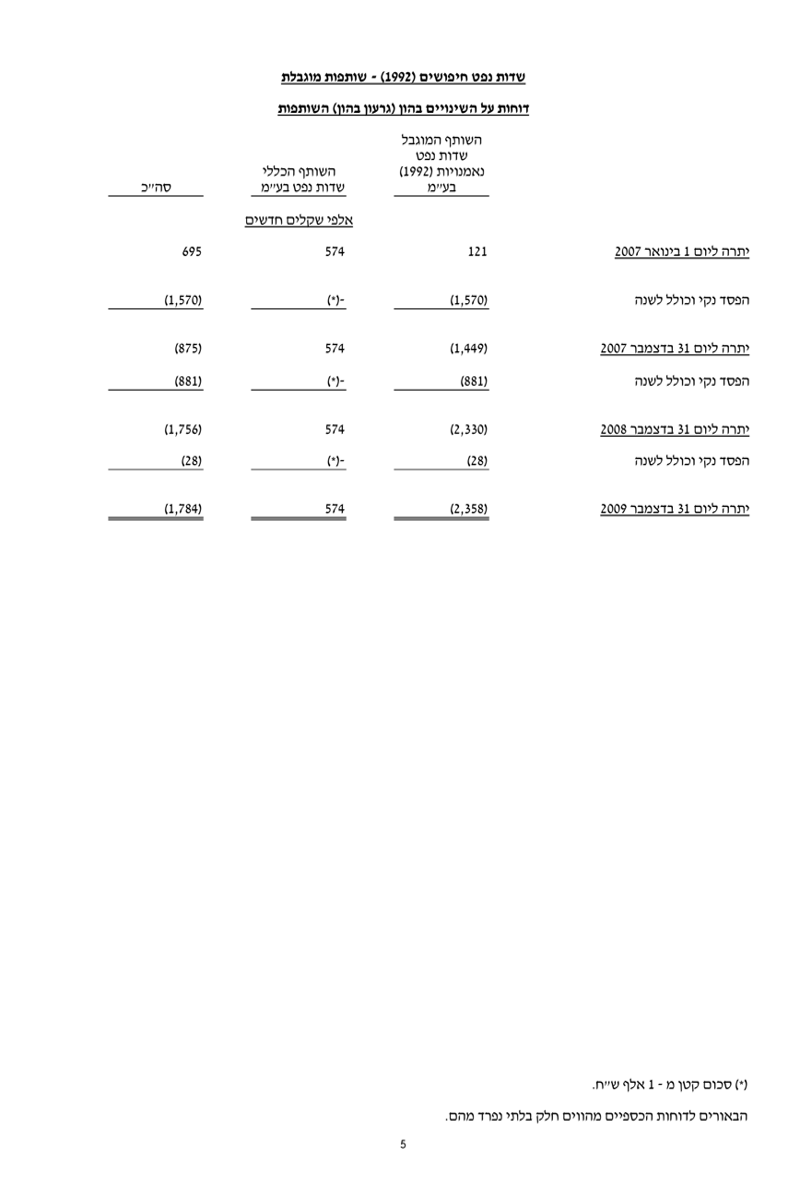

In [ ]:
from PIL import Image
def resize_to_1M_qwen(img, max_pixels=1_000_000, factor=28):
    w, h = img.size
    scale = min(1.0, (max_pixels / (w*h)) ** 0.5)
    w = int(w * scale) // factor * factor
    h = int(h * scale) // factor * factor
    return img.resize((w, h), Image.BICUBIC)


img = eval_dataset["train"]["image"][5]
img.save("inf.png")
img.resize((800,1200))

In [ ]:
import torch
from transformers import TextStreamer

# Extract instruction and system message from the dataset
instruction = eval_dataset["train"]["instruction"][0]
system_message = eval_dataset["train"]["system"][0] if "system" in eval_dataset["train"].column_names else print("invalid!@!!")

messages = [
    {
        "role": "system",
        "content": [{"type": "text", "text": system_message}]
    },
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": "/content/inf.png",
            },
            {"type": "text", "text": instruction},
        ],
    }
]

# Apply chat template with system message
inputs = processor.apply_chat_template(
    messages,
    tokenize=True,
    add_generation_prompt=True,
    return_dict=True,
    return_tensors="pt",
    enable_thinking=False,
)
inputs = inputs.to(model.device)

# Streamer (prints as it generates)
streamer = TextStreamer(
    tokenizer=processor.tokenizer if hasattr(processor, "tokenizer") else processor.tokenizer,
    skip_prompt=True,
    skip_special_tokens=True,
)

# Generate with streaming and specified parameters
_ = model.generate(
    **inputs,
    max_new_tokens=8096,
    streamer=streamer,
    do_sample=False
)

Keyword argument `enable_thinking` is not a valid argument for this processor and will be ignored.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


{"meta":{"entity_name":"שדות נפש חיפושים (1992) - שותפות מוגבלת","page_num":"5","page_type":"statements","statement_type":"statement_of_changes_in_equity","title":"דוחות על השינויים בהון (נרעון בהון) השותפות"},"facts":[{"value":"121","comment_ref":null,"note_flag":false,"note_name":null,"note_num":null,"note_ref":null,"period_type":"instant","period_start":null,"period_end":"2007-01-01","duration_type":null,"path":["יתרה ליום 1 בינואר 2007","השו״ף המוגבל","שדות נפש אאמנויות (1992) בע״מ"],"path_source":"observed","currency":"ILS","scale":1000,"value_type":"amount","value_context":"tabular"},{"value":"574","comment_ref":null,"note_flag":false,"note_name":null,"note_num":null,"note_ref":null,"period_type":"instant","period_start":null,"period_end":"2007-01-01","duration_type":null,"path":["יתרה ליום 1 בינואר 2007","השו״ף הכללי","שדות נפש בע״מ"],"path_source":"observed","currency":"ILS","scale":1000,"value_type":"amount","value_context":"tabular"},{"value":"695","comment_ref":null,"note_fl